# OTT Subscriber Churn Analysis — Phase 2: EDA & Visualization <span style="float:right; font-size: 16px; font-weight: normal; margin-top: 15px;">Author: Girish Pathak</span>

In [2]:
"""
=============================================================================
OTT Subscriber Churn Analysis — Phase 2: EDA & Visualization
=============================================================================
Project     : ott-subscriber-churn-analysis
Description : Exploratory Data Analysis on cleaned master churn dataset.
              Answers 6 key business questions with charts & insights.
 

Business Questions Answered:
  Q1. What is the overall customer churn rate?
  Q2. Which subscription plan has the highest churn rate?
  Q3. What is the impact of contract type on customer churn?
  Q4. Are customers who file complaints more likely to churn?
  Q5. What is the relationship between age groups and customer churn?
  Q6. What are the main reasons for customer churn? (Cancellation Reasons)
 
Tech Stack  : Pandas, NumPy, Matplotlib, Seaborn, SQLite3
Input       : customer_churn_clean.db  (Phase 1 output)
=============================================================================
"""

 
# Import Libraries
 
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')   # Clean output — no unnecessary warnings

## Step 1: Chart Style Settings

In [3]:
# Chart Style Settings 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
})

# Colors
COLOR_ACTIVE  = "#2ecc71"   # Green  — active customers
COLOR_CHURN   = "#e74c3c"   # Red    — churned customers
COLOR_NEUTRAL = "#3498db"   # Blue   — general bars
COLOR_ACCENT  = "#f39c12"   # Orange — highlights

print("✅ Libraries loaded successfully!")
print("✅ Chart settings applied!")

✅ Libraries loaded successfully!
✅ Chart settings applied!


## STEP 2: DATA LOAD FROM DATABASE

In [4]:
conn = sqlite3.connect("customer_churn_clean.db")
df = pd.read_sql("SELECT * FROM master_churn", conn)
conn.close()

# Sanity Check 
print(f"  ✓ Data loaded!")
print(f"  Shape     : {df.shape}")
print(f"  Columns   : {df.columns.tolist()}")
print(f"\n  Churn breakdown:")
print(df["churn_flag"].value_counts().rename({0:"Active", 1:"Churned"}))
print(f"\nSample data:")
df.head(3)

  ✓ Data loaded!
  Shape     : (21, 24)
  Columns   : ['customerid', 'name', 'country', 'state', 'gender', 'dob', 'age', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'tenure_months', 'revenue_lost', 'total_complaints', 'has_escalation', 'avg_csat', 'has_complaint']

  Churn breakdown:
churn_flag
Active     15
Churned     6
Name: count, dtype: int64

Sample data:


,customerid,name,country,state,gender,dob,age,subscription_start_date,subscription_type,renewal_date,...,monthly_charges,cltv,churn_score,churn_flag,tenure_months,revenue_lost,total_complaints,has_escalation,avg_csat,has_complaint
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,44,2021-03-15 00:00:00,Referral,2025-03-15,...,13.99,627,12,0,65,0.00,0,0,0.0,0
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,30,2020-08-01 00:00:00,Paid,2024-08-01,...,12.99,1150,91,1,72,12.99,2,1,35.0,1
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,48,2022-11-20 00:00:00,Organic,2025-11-20,...,6.99,210,34,0,44,0.00,0,0,0.0,0


## STEP 3: AGE GROUP COLUMN

In [5]:
# Age is a continuous numeric variable (21–49).
# Grouping it into age ranges makes the analysis more meaningful.
# pd.cut() is used to divide numeric values into specified intervals (bins).

df["age_group"] = pd.cut(
    df["age"],
    bins   = [20, 30, 40, 50],
    labels = ["21-30", "31-40", "41-50"]
)

print("  ✓ Age groups created!")
print(f"\n  Distribution:")
print(df["age_group"].value_counts().sort_index())
print(f"\n  Sample:")
df[["customerid", "age", "age_group"]].head(5)

  ✓ Age groups created!

  Distribution:
age_group
21-30    6
31-40    7
41-50    8
Name: count, dtype: int64

  Sample:


,customerid,age,age_group
0,0002-ORFBO,44,41-50
1,0003-MKNFE,30,21-30
2,0004-TLHLJ,48,41-50
3,0011-IGKFF,24,21-30
4,0013-EXCHZ,36,31-40


## STEP 4: Business Question 1: Overall Churn Rate

  Total     : 21
  Churned   : 6 (28.6%)
  Active    : 15
  Rev Lost  : ₹73.94


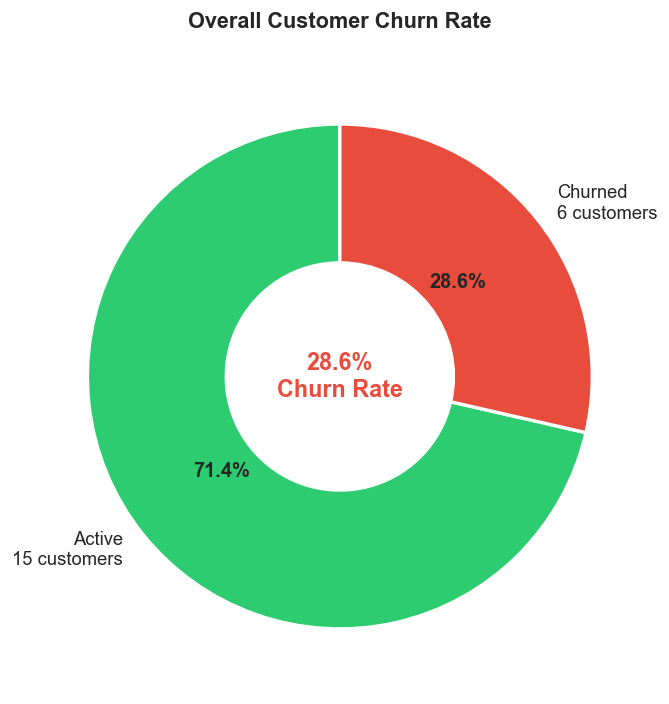


   INSIGHT — Overall Churn
  Total Customers     : 21
  Churned             : 6 (28.6%)
  Active              : 15 (71.4%)
  Monthly Rev Lost    : ₹73.94
──────────────────────────────────────────────────
   ACTION: 28.6% churn rate is HIGH.
     Industry benchmark: 5-7% monthly.
     Immediate retention strategy needed.



In [7]:
#  Q1. What is the overall customer churn rate?


# Calculate Numbers
total      = len(df)
churned    = int(df["churn_flag"].sum())
active     = total - churned
churn_rate = round((churned / total) * 100, 1)
rev_lost   = df["revenue_lost"].sum()

print(f"  Total     : {total}")
print(f"  Churned   : {churned} ({churn_rate}%)")
print(f"  Active    : {active}")
print(f"  Rev Lost  : ₹{rev_lost:.2f}")

# Donut Chart
fig, ax = plt.subplots(figsize=(6, 6))

sizes  = [active, churned]
colors = [COLOR_ACTIVE, COLOR_CHURN]
labels = [f"Active\n{active} customers",
          f"Churned\n{churned} customers"]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels     = labels,
    colors     = colors,
    autopct    = "%1.1f%%",
    startangle = 90,
    wedgeprops = dict(width=0.55, edgecolor="white", linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontweight("bold")
    autotext.set_fontsize(12)

# Churn rate text in Center
ax.text(0, 0, f"{churn_rate}%\nChurn Rate",
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        color=COLOR_CHURN)

ax.set_title("Overall Customer Churn Rate", pad=20)
plt.tight_layout()
plt.savefig("chart1_overall_churn.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Business Insight
print(f"""
{'='*50}
   INSIGHT — Overall Churn
{'='*50}
  Total Customers     : {total}
  Churned             : {churned} ({churn_rate}%)
  Active              : {active} ({100-churn_rate}%)
  Monthly Rev Lost    : ₹{rev_lost:.2f}
{'─'*50}
   ACTION: {churn_rate}% churn rate is HIGH.
     Industry benchmark: 5-7% monthly.
     Immediate retention strategy needed.
{'='*50}
""")

## STEP 5: Business Question 2: Plan Type vs Churn

  Plan-wise summary:
  plan_type  churned  total  churn_pct
0     Basic        3      5       60.0
2  Standard        2      9       22.2
1   Premium        1      7       14.3


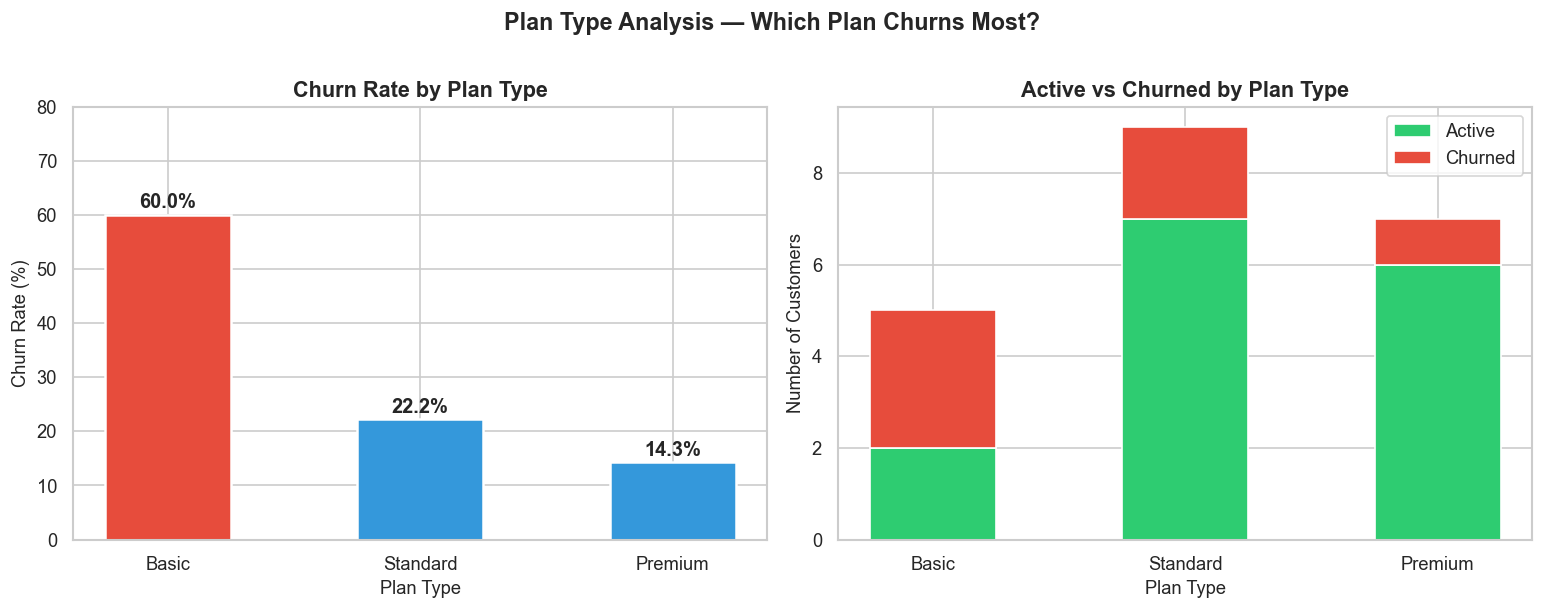


   INSIGHT — Churn by Plan Type
  Basic Plan    : High churn    🔴 CRITICAL
  Standard Plan : Medium churn  🟡 MODERATE
  Premium Plan  : Low churn     🟢 HEALTHY
──────────────────────────────────────────────────
     INSIGHT: Customers on the Basic plan 
     have the highest churn rate, likely 
     because they receive limited features 
     while paying the full subscription price.
   RECOMMENDATION: Offer upgrade incentives to 
     Basic plan customers or enhance the Basic 
     plan by adding more features and value to 
     improve customer retention.



In [8]:
# Q2. Which subscription plan has the highest churn rate?


# Calculate Churn Rate per Plan
# groupby() → Group the data by subscription plan.
# agg() → Calculate the number of churned customers, total customers, and churn rate for each group.

plan_churn = df.groupby("plan_type").agg(
    churned    = ("churn_flag", "sum"),
    total      = ("churn_flag", "count"),
    churn_rate = ("churn_flag", "mean")
).reset_index()

# Multiply by 100 to express the churn rate as a percentage.
plan_churn["churn_pct"] = (
    plan_churn["churn_rate"] * 100
).round(1)
plan_churn["active"] = (
    plan_churn["total"] - plan_churn["churned"]
)
# Sort the results by churn rate in descending order (highest first).
plan_churn = plan_churn.sort_values(
    "churn_pct", ascending=False
)

print("  Plan-wise summary:")
print(plan_churn[["plan_type","churned","total","churn_pct"]])

# Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart Left: Churn Rate % by Plan 
bar_colors = [
    COLOR_CHURN if p == plan_churn.iloc[0]["plan_type"]
    else COLOR_NEUTRAL
    for p in plan_churn["plan_type"]
]

bars = axes[0].bar(
    plan_churn["plan_type"],
    plan_churn["churn_pct"],
    color=bar_colors, edgecolor="white",
    linewidth=1.5, width=0.5
)

# Add Value labels

for bar, val in zip(bars, plan_churn["churn_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center", va="bottom",
        fontweight="bold", fontsize=12
    )

axes[0].set_title("Churn Rate by Plan Type")
axes[0].set_xlabel("Plan Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 80)

# Right: Stacked Count
axes[1].bar(
    plan_churn["plan_type"],
    plan_churn["active"],
    color=COLOR_ACTIVE,
    label="Active",
    edgecolor="white", width=0.5
)
axes[1].bar(
    plan_churn["plan_type"],
    plan_churn["churned"],
    bottom=plan_churn["active"],
    color=COLOR_CHURN,
    label="Churned",
    edgecolor="white", width=0.5
)

axes[1].set_title("Active vs Churned by Plan Type")
axes[1].set_xlabel("Plan Type")
axes[1].set_ylabel("Number of Customers")
axes[1].legend()

plt.suptitle(
    "Plan Type Analysis — Which Plan Churns Most?",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("chart2_plan_churn.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Business Insight
print(f"""
{'='*50}
   INSIGHT — Churn by Plan Type
{'='*50}
  Basic Plan    : High churn    🔴 CRITICAL
  Standard Plan : Medium churn  🟡 MODERATE
  Premium Plan  : Low churn     🟢 HEALTHY
{'─'*50}
     INSIGHT: Customers on the Basic plan 
     have the highest churn rate, likely 
     because they receive limited features 
     while paying the full subscription price.
   RECOMMENDATION: Offer upgrade incentives to 
     Basic plan customers or enhance the Basic 
     plan by adding more features and value to 
     improve customer retention.
{'='*50}
""")

## STEP 6: Business Question 3: Contract Type vs Churn

  Contract-wise summary:
  contract_type  churned  total  churn_pct
0        Annual        1     12        8.3
1       Monthly        5      9       55.6


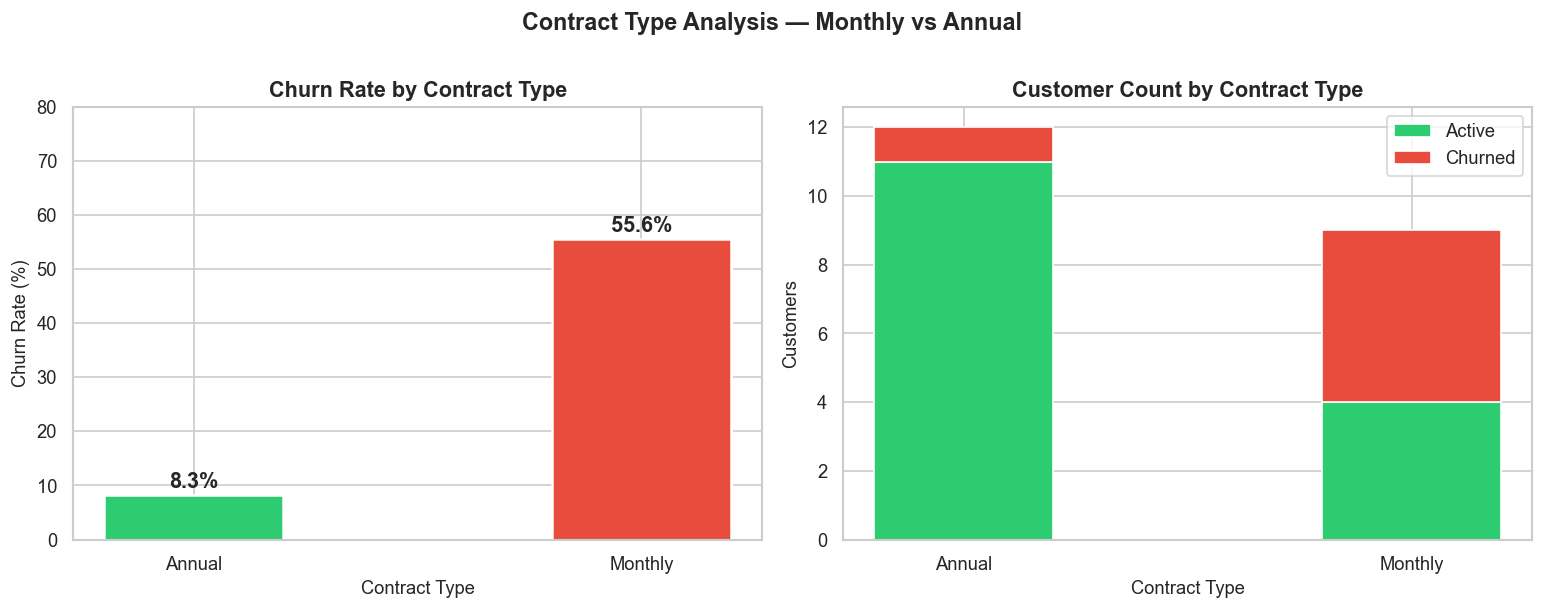


   INSIGHT — Contract Type vs Churn
  Monthly Contract : High churn rate   🔴 VERY HIGH
  Annual Contract  : Low churn rate    🟢 LOW
──────────────────────────────────────────────────
    ACTION: Customers on the Monthly plan 
    have a significantly higher churn rate.

    RECOMMENDATION: Encourage Monthly customers 
    to switch to the Annual plan by offering 
    promotions such as "2 months free on the 
    Annual plan."

    TARGET: Focus on Monthly subscribers who 
    have been with the service for more than 
    6 months.



In [9]:
#  Q3. What is the impact of contract type on customer churn?

# Calculate
contract_churn = df.groupby("contract_type").agg(
    churned   = ("churn_flag", "sum"),
    total     = ("churn_flag", "count"),
    churn_pct = ("churn_flag", "mean")
).reset_index()

contract_churn["churn_pct"] = (
    contract_churn["churn_pct"] * 100
).round(1)
contract_churn["active"] = (
    contract_churn["total"] - contract_churn["churned"]
)

print("  Contract-wise summary:")
print(contract_churn[["contract_type","churned",
                        "total","churn_pct"]])

# Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Churn Rate
ct_colors = [
    COLOR_CHURN if v > 30 else COLOR_ACTIVE
    for v in contract_churn["churn_pct"]
]

bars = axes[0].bar(
    contract_churn["contract_type"],
    contract_churn["churn_pct"],
    color=ct_colors,
    edgecolor="white",
    linewidth=1.5, width=0.4
)

for bar, val in zip(bars, contract_churn["churn_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center", va="bottom",
        fontweight="bold", fontsize=13
    )

axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 80)

# Right: Stacked Count
axes[1].bar(
    contract_churn["contract_type"],
    contract_churn["active"],
    color=COLOR_ACTIVE,
    label="Active",
    edgecolor="white", width=0.4
)
axes[1].bar(
    contract_churn["contract_type"],
    contract_churn["churned"],
    bottom=contract_churn["active"],
    color=COLOR_CHURN,
    label="Churned",
    edgecolor="white", width=0.4
)

axes[1].set_title("Customer Count by Contract Type")
axes[1].set_xlabel("Contract Type")
axes[1].set_ylabel("Customers")
axes[1].legend()

plt.suptitle(
    "Contract Type Analysis — Monthly vs Annual",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("chart3_contract_churn.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Business Insight
print(f"""
{'='*50}
   INSIGHT — Contract Type vs Churn
{'='*50}
  Monthly Contract : High churn rate   🔴 VERY HIGH
  Annual Contract  : Low churn rate    🟢 LOW
{'─'*50}
    ACTION: Customers on the Monthly plan 
    have a significantly higher churn rate.

    RECOMMENDATION: Encourage Monthly customers 
    to switch to the Annual plan by offering 
    promotions such as "2 months free on the 
    Annual plan."

    TARGET: Focus on Monthly subscribers who 
    have been with the service for more than 
    6 months.
{'='*50}
""")

## STEP 7: Business Question 4: Complaints vs Churn

  Complaint vs Churn:
           label  churned  total  churn_pct
0   No Complaint        0     14        0.0
1  Had Complaint        6      7       85.7


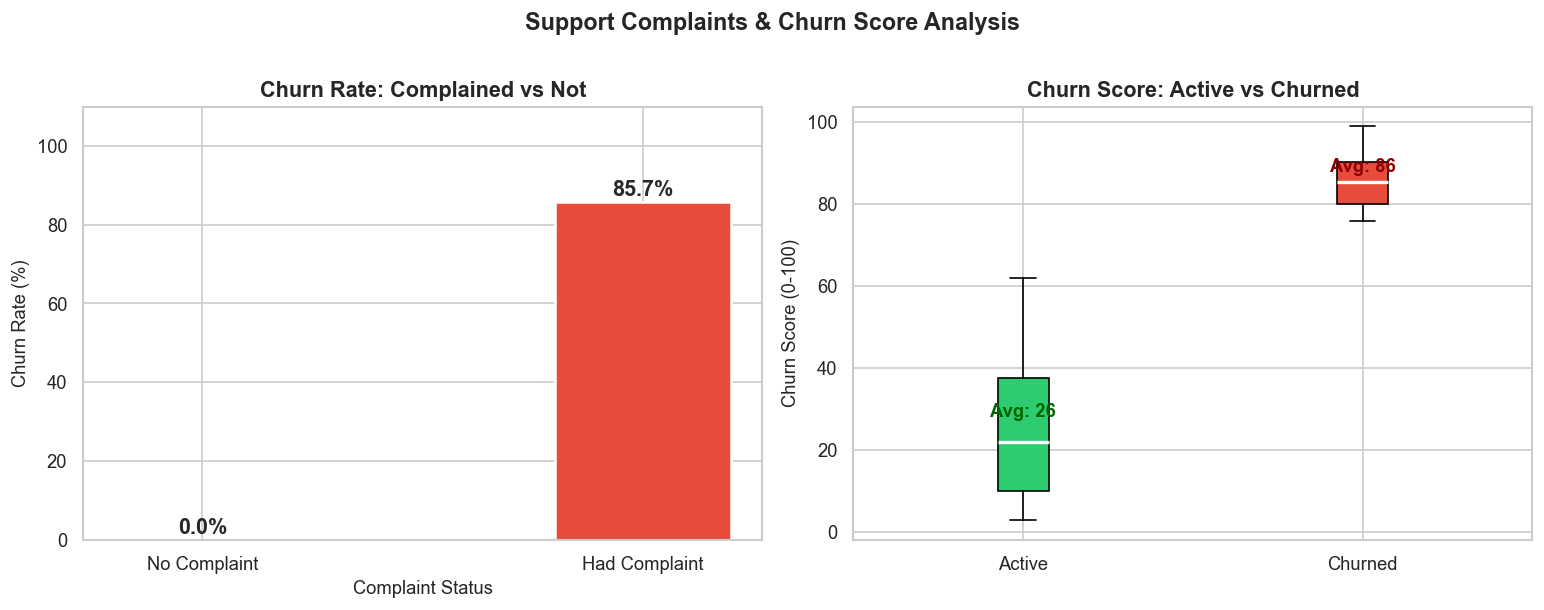


   INSIGHT — Complaints & Churn Score
  No Complaint  → Churn Rate: Low    🟢
  Had Complaint → Churn Rate: High   🔴 ALARMING
  Avg Score (Active)  : 26/100
  Avg Score (Churned) : 86/100
──────────────────────────────────────────────────
   ACTION: Customers who file complaints 
   are much more likely to churn.
   RECOMMENDATION: If a customer's CSAT 
   score is below 3, immediately refer 
   them to the Retention Team for proactive 
   follow-up.



In [10]:
#  Q4. Are customers who file complaints more likely to churn?

# Calculate
complaint_churn = df.groupby("has_complaint").agg(
    churned   = ("churn_flag", "sum"),
    total     = ("churn_flag", "count"),
    churn_pct = ("churn_flag", "mean")
).reset_index()

complaint_churn["churn_pct"] = (
    complaint_churn["churn_pct"] * 100
).round(1)
complaint_churn["label"] = complaint_churn[
    "has_complaint"
].map({0: "No Complaint", 1: "Had Complaint"})

print("  Complaint vs Churn:")
print(complaint_churn[["label","churned","total","churn_pct"]])

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Churn Rate
bars = axes[0].bar(
    complaint_churn["label"],
    complaint_churn["churn_pct"],
    color=[COLOR_ACTIVE, COLOR_CHURN],
    edgecolor="white",
    linewidth=1.5, width=0.4
)

for bar, val in zip(bars, complaint_churn["churn_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center", va="bottom",
        fontweight="bold", fontsize=13
    )

axes[0].set_title("Churn Rate: Complained vs Not")
axes[0].set_xlabel("Complaint Status")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 110)

# Right: Churn Score Boxplot
churn_score_data = [
    df[df["churn_flag"] == 0]["churn_score"].values,
    df[df["churn_flag"] == 1]["churn_score"].values
]

bp = axes[1].boxplot(
    churn_score_data,
    labels       = ["Active", "Churned"],
    patch_artist = True,
    medianprops  = dict(color="white", linewidth=2)
)

bp["boxes"][0].set_facecolor(COLOR_ACTIVE)
bp["boxes"][1].set_facecolor(COLOR_CHURN)

axes[1].set_title("Churn Score: Active vs Churned")
axes[1].set_ylabel("Churn Score (0-100)")

avg_active  = df[df["churn_flag"]==0]["churn_score"].mean()
avg_churned = df[df["churn_flag"]==1]["churn_score"].mean()

axes[1].text(1, avg_active + 2,
             f"Avg: {avg_active:.0f}",
             ha="center", color="darkgreen",
             fontweight="bold")
axes[1].text(2, avg_churned + 2,
             f"Avg: {avg_churned:.0f}",
             ha="center", color="darkred",
             fontweight="bold")

plt.suptitle(
    "Support Complaints & Churn Score Analysis",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("chart4_complaint_churnscore.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Business Insight
print(f"""
{'='*50}
   INSIGHT — Complaints & Churn Score
{'='*50}
  No Complaint  → Churn Rate: Low    🟢
  Had Complaint → Churn Rate: High   🔴 ALARMING
  Avg Score (Active)  : {avg_active:.0f}/100
  Avg Score (Churned) : {avg_churned:.0f}/100
{'─'*50}
   ACTION: Customers who file complaints 
   are much more likely to churn.
   RECOMMENDATION: If a customer's CSAT 
   score is below 3, immediately refer 
   them to the Retention Team for proactive 
   follow-up.
{'='*50}
""")

## STEP 8: Business Question 5: Age Group vs Churn

  Age group summary:
  age_group  churned  total  churn_pct  avg_tenure
0     21-30        1      6       16.7        70.7
1     31-40        2      7       28.6        51.1
2     41-50        3      8       37.5        50.1


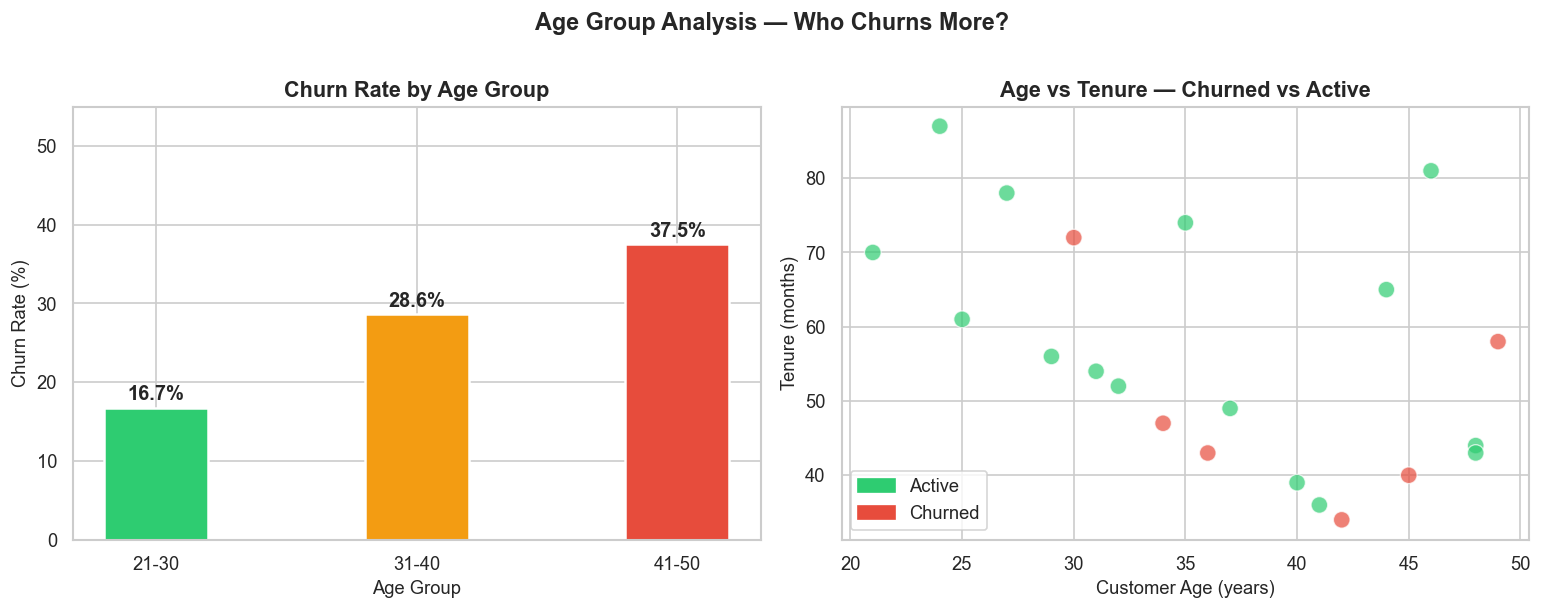


   INSIGHT — Age Group vs Churn
  21-30 : 16.7% churn  🟢 Most loyal
  31-40 : 28.6% churn  🟡 Moderate
  41-50 : 37.5% churn  🔴 High risk
──────────────────────────────────────────────────
     ACTION: Launch targeted retention campaigns 
     for customers in the 41–50 age group.

     RECOMMENDATION: Offer family plans or premium 
     content tailored to the interests and preferences 
     of this age group.



In [12]:
#  Q5. What is the relationship between age groups and customer churn?

# Calculate
age_churn = df.groupby("age_group", observed=True).agg(
    churned    = ("churn_flag", "sum"),
    total      = ("churn_flag", "count"),
    churn_pct  = ("churn_flag", "mean"),
    avg_tenure = ("tenure_months", "mean")
).reset_index()

age_churn["churn_pct"]  = (
    age_churn["churn_pct"] * 100
).round(1)
age_churn["avg_tenure"] = age_churn["avg_tenure"].round(1)

print("  Age group summary:")
print(age_churn)

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Churn Rate by Age
age_colors = [
    COLOR_ACTIVE if p < 25
    else COLOR_ACCENT if p < 35
    else COLOR_CHURN
    for p in age_churn["churn_pct"]
]

bars = axes[0].bar(
    age_churn["age_group"].astype(str),
    age_churn["churn_pct"],
    color=age_colors,
    edgecolor="white",
    linewidth=1.5, width=0.4
)

for bar, val in zip(bars, age_churn["churn_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center", va="bottom",
        fontweight="bold", fontsize=12
    )

axes[0].set_title("Churn Rate by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 55)

# Right: Age vs Tenure Scatter
scatter_colors = [
    COLOR_CHURN if f == 1 else COLOR_ACTIVE
    for f in df["churn_flag"]
]

axes[1].scatter(
    df["age"],
    df["tenure_months"],
    c=scatter_colors,
    alpha=0.7, s=100,
    edgecolors="white", linewidth=0.8
)

axes[1].set_title("Age vs Tenure — Churned vs Active")
axes[1].set_xlabel("Customer Age (years)")
axes[1].set_ylabel("Tenure (months)")

red_dot   = mpatches.Patch(color=COLOR_CHURN,  label="Churned")
green_dot = mpatches.Patch(color=COLOR_ACTIVE, label="Active")
axes[1].legend(handles=[green_dot, red_dot])

plt.suptitle(
    "Age Group Analysis — Who Churns More?",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("chart5_age_churn.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Business Insight

print(f"""
{'='*50}
   INSIGHT — Age Group vs Churn
{'='*50}
  21-30 : {age_churn.iloc[0]['churn_pct']}% churn  🟢 Most loyal
  31-40 : {age_churn.iloc[1]['churn_pct']}% churn  🟡 Moderate
  41-50 : {age_churn.iloc[2]['churn_pct']}% churn  🔴 High risk
{'─'*50}
     ACTION: Launch targeted retention campaigns 
     for customers in the 41–50 age group.

     RECOMMENDATION: Offer family plans or premium 
     content tailored to the interests and preferences 
     of this age group.
{'='*50}
""")

## STEP 9: Business Question 6: Cancellation Reasons

  Cancellation reasons:
                   reason  count   pct
0  Switched to competitor      2  33.3
1           Too expensive      1  16.7
2      Not enough content      1  16.7
3  Poor streaming quality      1  16.7
4  Forgot to cancel trial      1  16.7


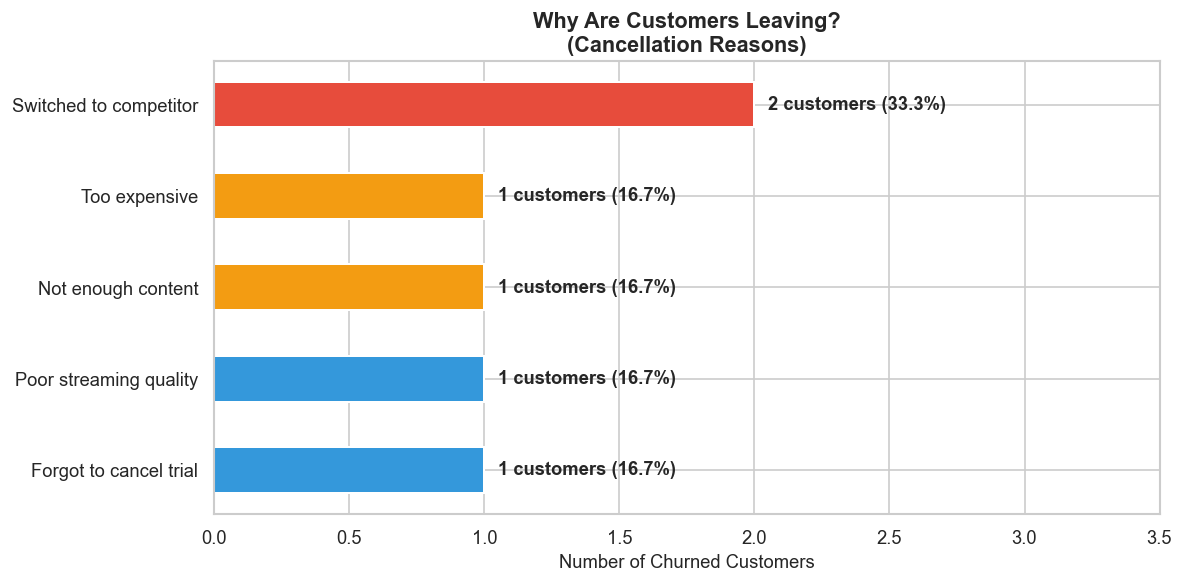


   INSIGHT — Why Customers Leave
  Switched to competitor        : 33.3%
  Too expensive                 : 16.7%
  Not enough content            : 16.7%
  Poor streaming quality        : 16.7%
  Forgot to cancel trial        : 16.7%
──────────────────────────────────────────────────
   ACTION PLAN:
  1. Competitor switch → Exclusive content
  2. Too expensive     → Loyalty discounts
  3. Poor quality      → Tech infra fix
  4. Less content      → Regional content add



In [13]:
#  Q6. What are the main reasons for customer churn? (Cancellation Reasons)


# Calculate
# Analyze cancellation reasons for churned customers only.
reasons = df[df["churn_flag"]==1][
    "cancellation_reason"
].value_counts()

reasons_df = reasons.reset_index()
reasons_df.columns = ["reason", "count"]
reasons_df["pct"] = (
    reasons_df["count"] /
    reasons_df["count"].sum() * 100
).round(1)

print("  Cancellation reasons:")
print(reasons_df)

# Horizontal Bar Chart-Better for long text
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [
    COLOR_CHURN, COLOR_ACCENT,
    COLOR_ACCENT, COLOR_NEUTRAL, COLOR_NEUTRAL
][:len(reasons_df)]

bars = ax.barh(
    reasons_df["reason"],
    reasons_df["count"],
    color=bar_colors,
    edgecolor="white",
    linewidth=1.2, height=0.5
)

# Value + Percentage labels
for bar, count, pct in zip(
    bars, reasons_df["count"], reasons_df["pct"]
):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{count} customers ({pct}%)",
        va="center",
        fontsize=11, fontweight="bold"
    )

ax.set_title(
    "Why Are Customers Leaving?\n(Cancellation Reasons)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Number of Churned Customers")
ax.set_xlim(0, reasons_df["count"].max() + 1.5)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("chart6_cancellation_reasons.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Business Insight

print(f"""
{'='*50}
   INSIGHT — Why Customers Leave
{'='*50}""")
for _, row in reasons_df.iterrows():
    print(f"  {row['reason']:<30}: {row['pct']}%")
print(f"""{'─'*50}
   ACTION PLAN:
  1. Competitor switch → Exclusive content
  2. Too expensive     → Loyalty discounts
  3. Poor quality      → Tech infra fix
  4. Less content      → Regional content add
{'='*50}
""")

## STEP 10: Final Executive Dashboard

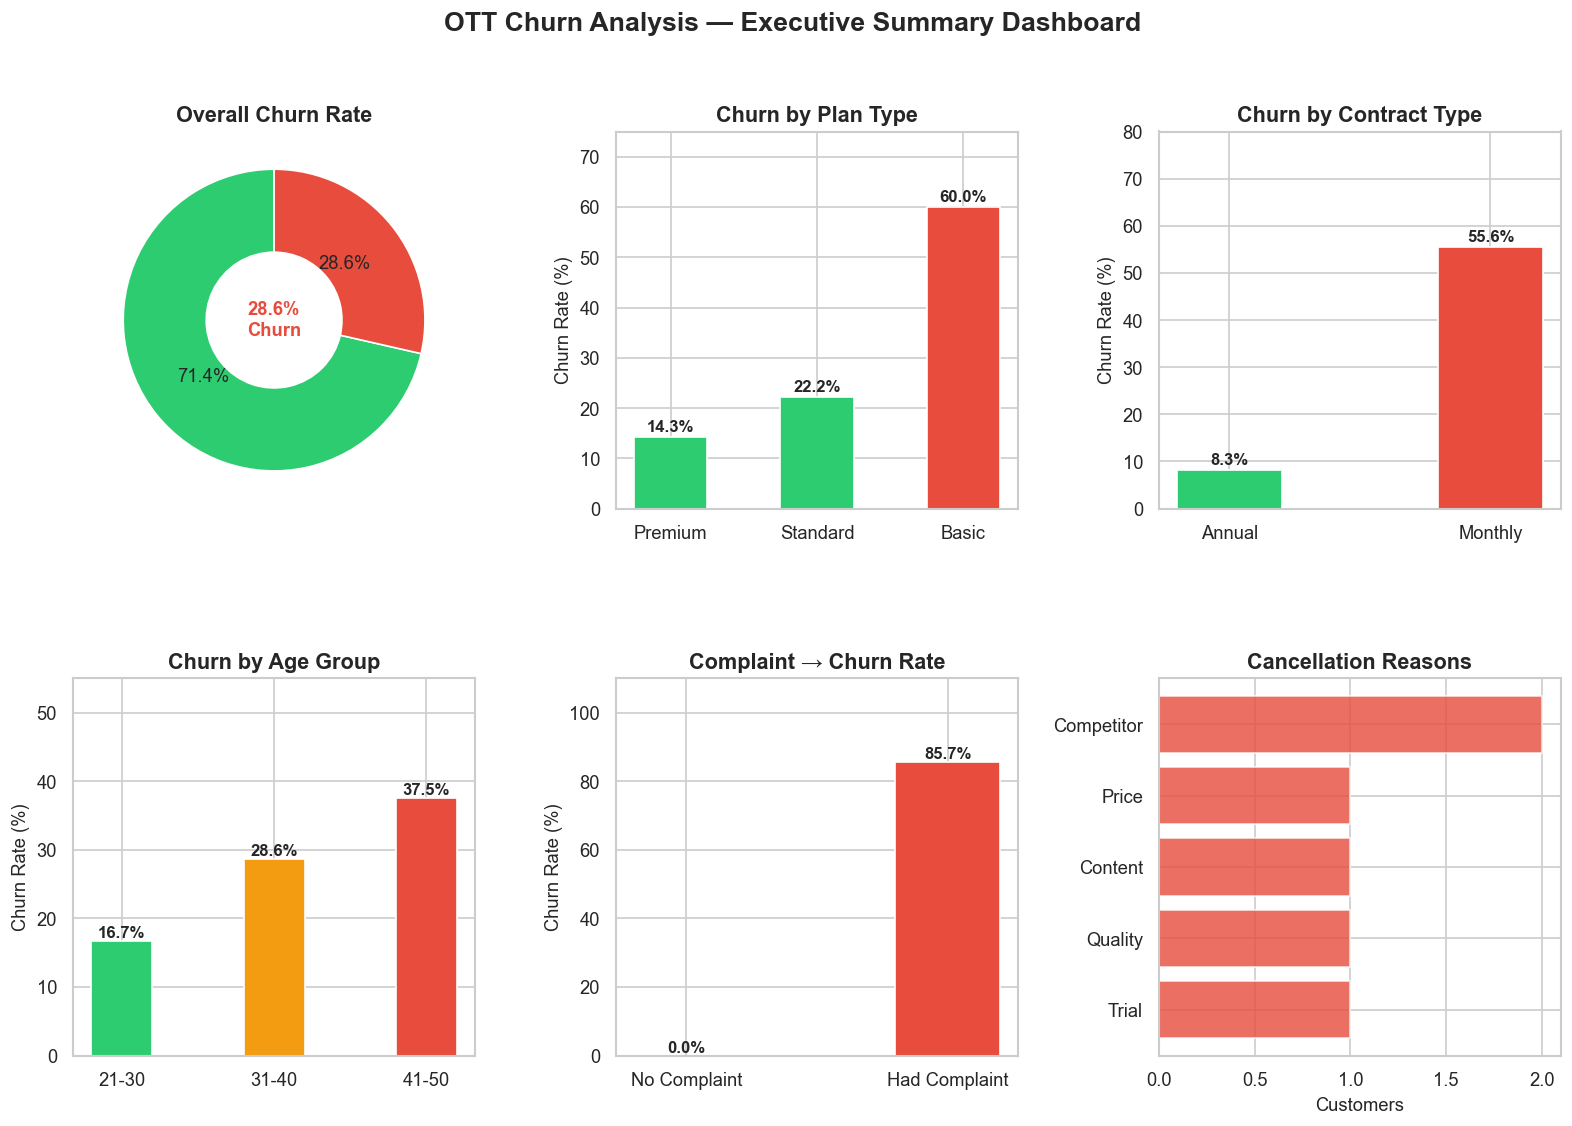

  ✅ Executive Dashboard saved!


In [14]:
# EXECUTIVE SUMMARY DASHBOARD

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "OTT Churn Analysis — Executive Summary Dashboard",
    fontsize=16, fontweight="bold", y=0.98
)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# Panel 1: Overall Churn
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(
    [active, churned],
    colors     = [COLOR_ACTIVE, COLOR_CHURN],
    autopct    = "%1.1f%%",
    startangle = 90,
    wedgeprops = dict(width=0.55, edgecolor="white")
)
ax1.text(0, 0, f"{churn_rate}%\nChurn",
         ha="center", va="center",
         fontsize=11, fontweight="bold",
         color=COLOR_CHURN)
ax1.set_title("Overall Churn Rate")

# Panel 2: Plan Type
ax2 = fig.add_subplot(gs[0, 1])
plan_s = plan_churn.sort_values("churn_pct")
p_colors = [
    COLOR_ACTIVE if v < 30 else COLOR_CHURN
    for v in plan_s["churn_pct"]
]
ax2.bar(
    plan_s["plan_type"],
    plan_s["churn_pct"],
    color=p_colors, edgecolor="white", width=0.5
)
for i, (_, row) in enumerate(plan_s.iterrows()):
    ax2.text(i, row["churn_pct"] + 1,
             f"{row['churn_pct']}%",
             ha="center", fontweight="bold", fontsize=10)
ax2.set_title("Churn by Plan Type")
ax2.set_ylabel("Churn Rate (%)")
ax2.set_ylim(0, 75)

# Panel 3: Contract Type
ax3 = fig.add_subplot(gs[0, 2])
ct = contract_churn.sort_values("churn_pct")
ct_c = [
    COLOR_ACTIVE if v < 20 else COLOR_CHURN
    for v in ct["churn_pct"]
]
ax3.bar(
    ct["contract_type"],
    ct["churn_pct"],
    color=ct_c, edgecolor="white", width=0.4
)
for i, (_, row) in enumerate(ct.iterrows()):
    ax3.text(i, row["churn_pct"] + 1,
             f"{row['churn_pct']}%",
             ha="center", fontweight="bold", fontsize=10)
ax3.set_title("Churn by Contract Type")
ax3.set_ylabel("Churn Rate (%)")
ax3.set_ylim(0, 80)

# Panel 4: Age Group
ax4 = fig.add_subplot(gs[1, 0])
age_c = [COLOR_ACTIVE, COLOR_ACCENT, COLOR_CHURN]
bars4 = ax4.bar(
    age_churn["age_group"].astype(str),
    age_churn["churn_pct"],
    color=age_c, edgecolor="white", width=0.4
)
for bar, val in zip(bars4, age_churn["churn_pct"]):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{val}%",
        ha="center", fontweight="bold", fontsize=10
    )
ax4.set_title("Churn by Age Group")
ax4.set_ylabel("Churn Rate (%)")
ax4.set_ylim(0, 55)

# Panel 5: Complaint Impact
ax5 = fig.add_subplot(gs[1, 1])
comp_vals = complaint_churn["churn_pct"].tolist()
comp_labs = complaint_churn["label"].tolist()
bars5 = ax5.bar(
    comp_labs, comp_vals,
    color=[COLOR_ACTIVE, COLOR_CHURN],
    edgecolor="white", width=0.4
)
for bar, val in zip(bars5, comp_vals):
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{val}%",
        ha="center", fontweight="bold", fontsize=10
    )
ax5.set_title("Complaint → Churn Rate")
ax5.set_ylabel("Churn Rate (%)")
ax5.set_ylim(0, 110)

# Panel 6: Cancellation Reasons
ax6 = fig.add_subplot(gs[1, 2])
reason_short = {
    "Switched to competitor" : "Competitor",
    "Too expensive"          : "Price",
    "Not enough content"     : "Content",
    "Poor streaming quality" : "Quality",
    "Forgot to cancel trial" : "Trial"
}
reasons_df["short"] = reasons_df["reason"].map(reason_short)
ax6.barh(
    reasons_df["short"],
    reasons_df["count"],
    color=COLOR_CHURN,
    alpha=0.8, edgecolor="white"
)
ax6.set_title("Cancellation Reasons")
ax6.set_xlabel("Customers")
ax6.invert_yaxis()

plt.savefig("dashboard_executive_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("  ✅ Executive Dashboard saved!")

## STEP 11: Final Business Report

In [18]:
# FINAL BUSINESS REPORT

print(f"""
{'═'*52}
      OTT CHURN ANALYSIS — EXECUTIVE REPORT            
{'═'*52}                                                
                                                       
  KEY METRICS                                           
  Total Customers    : {total:<5} Active: {active:<5}  Churned: {churned:<3}            
  Churn Rate         : {churn_rate}%  (Benchmark: 5-7%) 
 Monthly Rev Lost   : ₹{rev_lost:.2f}                  
                                                        
  TOP RISK SEGMENTS                                     
  • Basic Plan customers     → Highest churn   🔴        
  • Monthly contract         → Very high churn 🔴      
  • Age 41-50 group          → High risk       🔴            
  • Customers who complained → Very high churn 🔴      
                                                        
  TOP CHURN REASONS                                     
  1. Switched to competitor  (most common)              
  2. Too expensive                                      
  3. Not enough content                                 
  4. Poor streaming quality                             
                                                        
 RECOMMENDED ACTIONS                                   
  1. Monthly→Annual: Offer 2 months free                
  2. Basic users: Trial premium upgrade                 
  3. Post-complaint: Follow up within 24hrs             
  4. Age 41-50: Family/premium content deals            
  5. Price sensitive: Loyalty discount program          
{'═'*52}

Charts Saved:
  ✅ chart1_overall_churn.png
  ✅ chart2_plan_churn.png
  ✅ chart3_contract_churn.png
  ✅ chart4_complaint_churnscore.png
  ✅ chart5_age_churn.png
  ✅ chart6_cancellation_reasons.png
  ✅ dashboard_executive_summary.png

✅ COMPLETED!
""")


════════════════════════════════════════════════════
      OTT CHURN ANALYSIS — EXECUTIVE REPORT            
════════════════════════════════════════════════════                                                

  KEY METRICS                                           
  Total Customers    : 21    Active: 15     Churned: 6              
  Churn Rate         : 28.6%  (Benchmark: 5-7%) 
 Monthly Rev Lost   : ₹73.94                  

  TOP RISK SEGMENTS                                     
  • Basic Plan customers     → Highest churn   🔴        
  • Monthly contract         → Very high churn 🔴      
  • Age 41-50 group          → High risk       🔴            
  • Customers who complained → Very high churn 🔴      

  TOP CHURN REASONS                                     
  1. Switched to competitor  (most common)              
  2. Too expensive                                      
  3. Not enough content                                 
  4. Poor streaming quality                        